# Customer Churn Prediction using Machine Learning
This project predicts whether a customer will leave a telecom company using machine learning.

## Problem Statement

Customer churn is a major issue in the telecom industry.
When customers stop using a company's service, it results in revenue loss.

The goal of this project is to build a machine learning model that predicts
whether a customer is likely to churn based on customer data such as
contract type, internet service, monthly charges, and tenure.

## Import Libraries and Load Datasets

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Exploration

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Cleaning

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


## Data Visualization

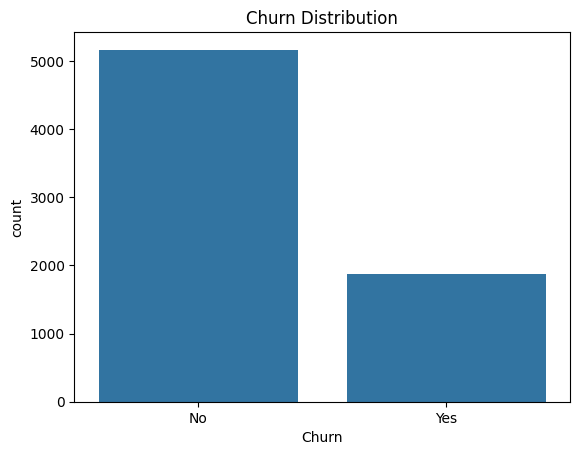

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

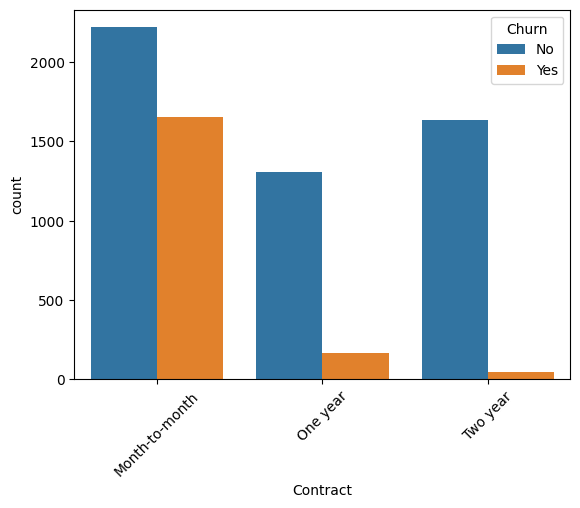

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

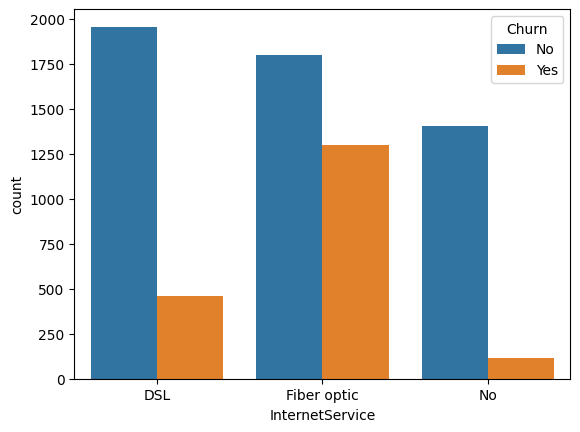

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

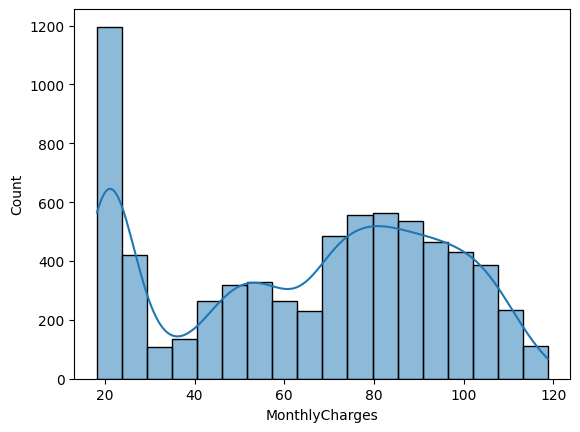

In [ ]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

## Feature Encoding

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
pred = model.predict(X_test)

## Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.7846481876332623

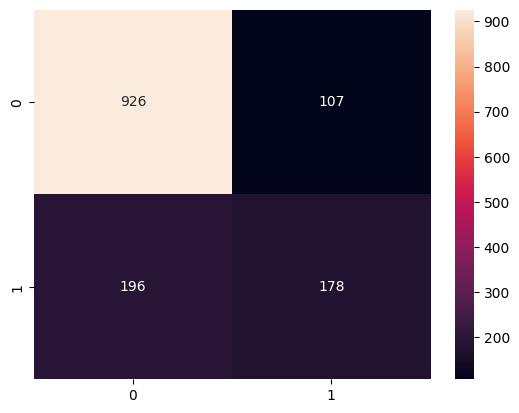

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

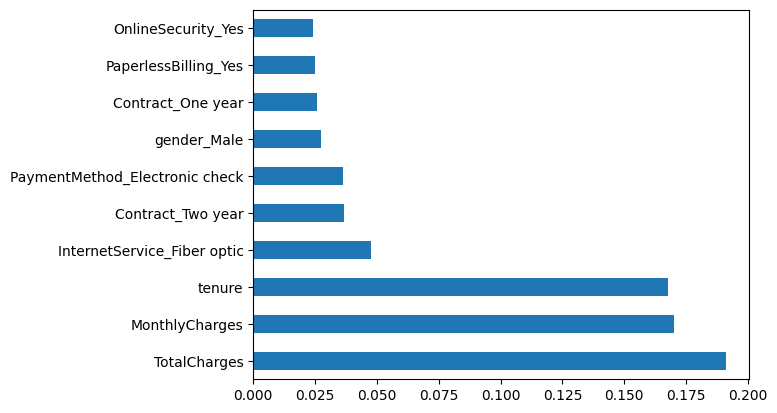

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh')
plt.show()

## Dataset

The dataset used in this project is the Telco Customer Churn Dataset.

It contains information about telecom customers including:

- Customer tenure
- Internet service type
- Contract type
- Payment method
- Monthly charges
- Total charges

The dataset contains around 7000 customer records.

## Technologies Used

Python
Pandas
NumPy
Matplotlib
Seaborn
Scikit-learn

## Methodology

The following steps were performed:

1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Training
6. Model Evaluation

## Machine Learning Model

Random Forest Classifier was used to train the model and predict customer churn.

## Results

The Random Forest model achieved around 80% accuracy
in predicting customer churn.

Important factors influencing churn include:
- Monthly Charges
- Contract Type
- Customer Tenure

## Conclusion

Customer churn prediction helps businesses identify customers
who are likely to leave the service.

Companies can use these insights to improve customer retention
strategies and reduce revenue loss.